In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA

In [4]:
#pwd
path='/Users/eimonsoe/Documents/Final Year (Second Semester)/Advance ML/Midterm Group/CreditCardData.csv'
df=pd.read_csv(path)
print("File loaded successfully!")

File loaded successfully!


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


In [6]:
df.isna().sum()

Sl_No                  0
Customer Key           0
Avg_Credit_Limit       0
Total_Credit_Cards     0
Total_visits_bank      0
Total_visits_online    0
Total_calls_made       0
dtype: int64

In [7]:
#Drop IDs that don't help with clustering
X = df.drop(['Sl_No', 'Customer Key'], axis=1)

In [10]:
#Scaling: Crucial for HAC!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

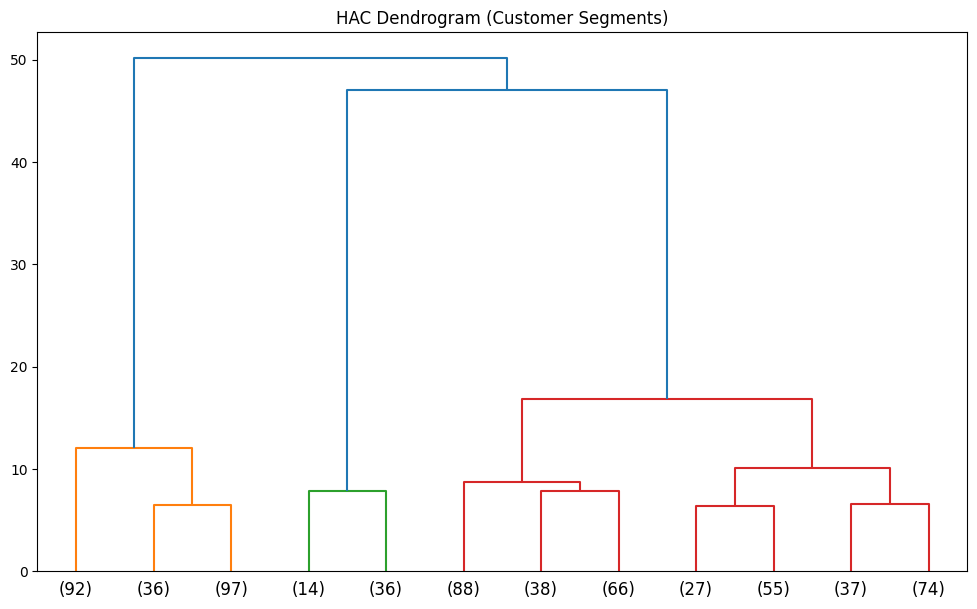

In [19]:
#Dendrogram
plt.figure(figsize=(12, 7))
Z = linkage(X_scaled, method='ward') 
dendrogram(Z, truncate_mode='lastp', p=12) #Truncate to make it clean
plt.title("HAC Dendrogram (Customer Segments)")
plt.show()

In [14]:
#Use n_clusters=3 because my chart showed 3 main branches
model = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
df['Cluster'] = model.fit_predict(X_scaled)
score = silhouette_score(X_scaled, df['Cluster'])
print(f"Implementation Result - Silhouette Score: {score:.4f}")

Implementation Result - Silhouette Score: 0.5148


The model successfully separated the 660 customers into 3 distinct groups. A score of 0.51 indicates that the customers within each cluster are more than 50% more similar to their own group than they are to the neighboring groups.

--- Comparing Cluster Counts with PCA Visuals ---
For K = 2, Silhouette Score is: 0.4177
For K = 3, Silhouette Score is: 0.5148
For K = 4, Silhouette Score is: 0.3491
For K = 5, Silhouette Score is: 0.2571
For K = 6, Silhouette Score is: 0.2303


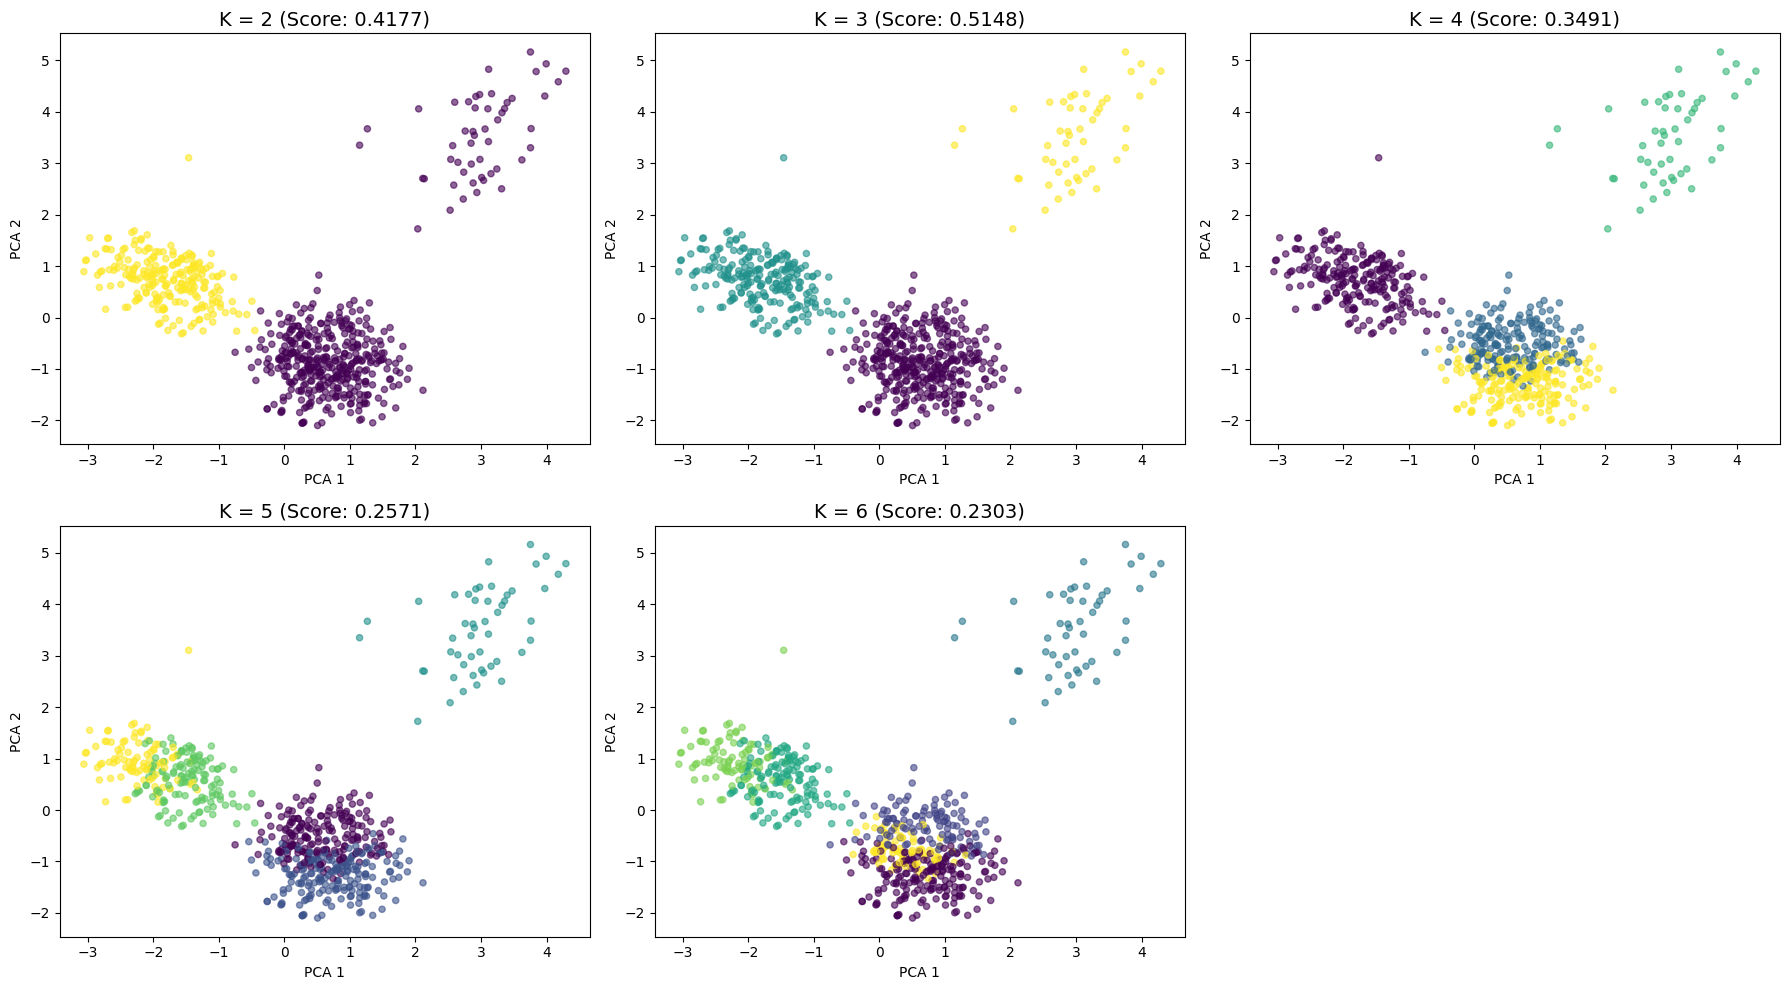

In [ ]:
#I want to test other cluster counts to see if I can get a better silhouette score, and also visualize the clusters with PCA (since HAC is hard to visualize in high dimensions)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
k_range = [2, 3, 4, 5, 6]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten() #Make it easier to loop through
print("--- Comparing Cluster Counts with PCA Visuals ---")
for i, k in enumerate(k_range):
    model = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"For K = {k}, Silhouette Score is: {score:.4f}")
    
    # Plot on the subplot
    ax = axes[i]
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.6, s=20)
    ax.set_title(f"K = {k} (Score: {score:.4f})", fontsize=14)
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")
axes[-1].axis('off') #Hide the last empty subplot (since I want only 5 plots in a 6-plot grid)
plt.tight_layout()
plt.show()

When K=2, the clusters were too broad and mixed different types of customers together. When K=4, the clusters became too specific, and the groups started to overlap. K=3 hit the 'Sweet Spot' where each group is distinct and logically separated.

In [31]:
#Select only the features and the cluster labels
features = ['Avg_Credit_Limit', 'Total_Credit_Cards', 'Total_visits_bank', 'Total_visits_online', 'Total_calls_made']
analysis = df.groupby('Cluster')[features].mean()
print("--- Cluster Profiles (Averages) ---")
print(analysis.round(2))

--- Cluster Profiles (Averages) ---
         Avg_Credit_Limit  Total_Credit_Cards  Total_visits_bank  \
Cluster                                                            
0                33851.95                5.52               3.49   
1                12151.11                2.42               0.94   
2               141040.00                8.74               0.60   

         Total_visits_online  Total_calls_made  
Cluster                                         
0                       0.98              1.99  
1                       3.55              6.86  
2                      10.90              1.08  


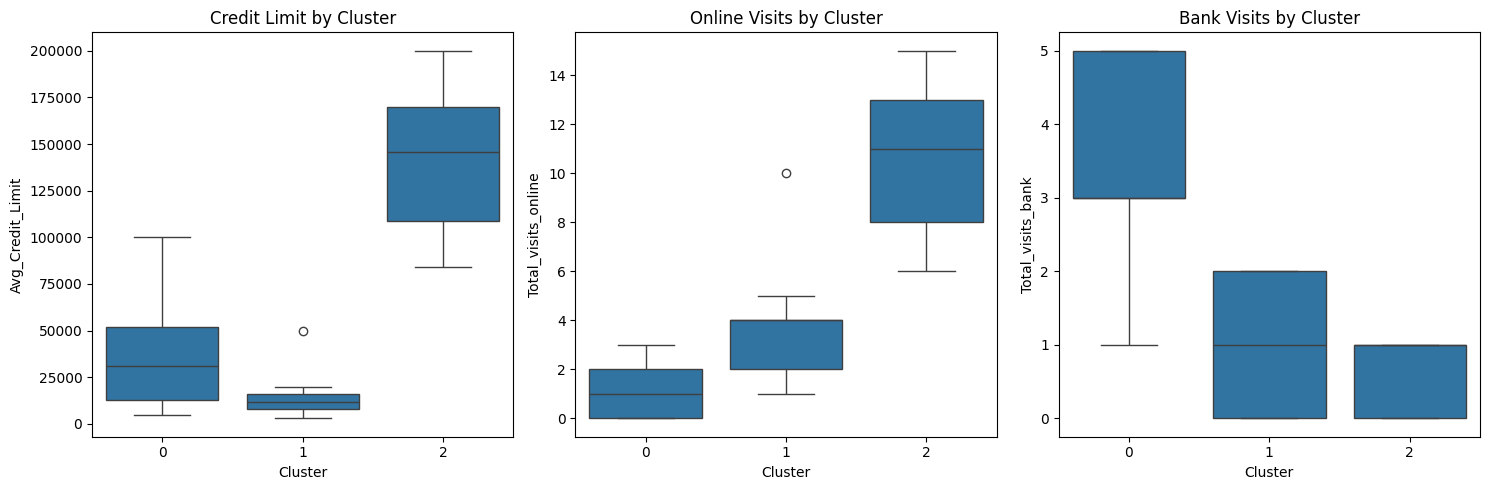

In [ ]:
import seaborn as sns
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(x='Cluster', y='Avg_Credit_Limit', data=df)
plt.title('Credit Limit by Cluster')

plt.subplot(1, 3, 2)
sns.boxplot(x='Cluster', y='Total_visits_online', data=df)
plt.title('Online Visits by Cluster')

plt.subplot(1, 3, 3)
sns.boxplot(x='Cluster', y='Total_visits_bank', data=df)
plt.title('Bank Visits by Cluster')

plt.tight_layout()
plt.show()

/var/folders/d3/15c907m53p54ndqkwnp7x7fr0000gn/T/ipykernel_4744/599704537.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster_Name', y='Avg_Credit_Limit', data=df, palette='viridis')


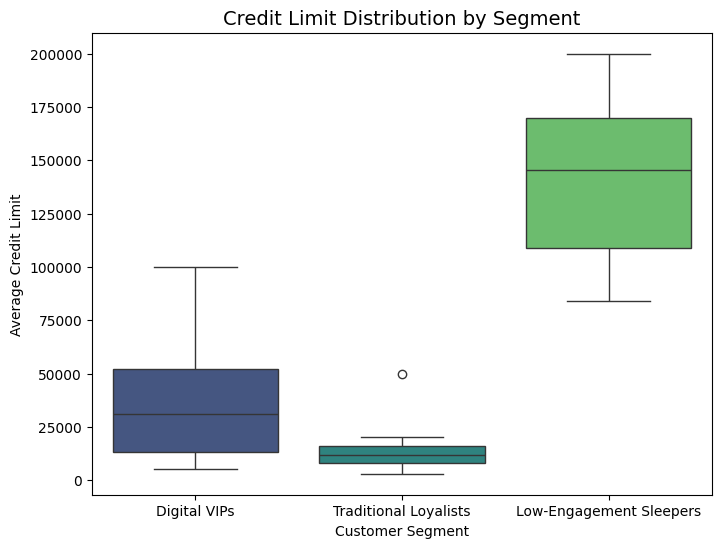

In [32]:
# Create a dictionary to map IDs to Names
# (Double check your boxplots to make sure the ID matches the behavior!)
cluster_names = {
    0: 'Digital VIPs',
    1: 'Traditional Loyalists',
    2: 'Low-Engagement Sleepers'
}

# Apply the names to the dataframe
df['Cluster_Name'] = df['Cluster'].map(cluster_names)

# Re-run one of your boxplots with the names
plt.figure(figsize=(8, 6))
sns.boxplot(x='Cluster_Name', y='Avg_Credit_Limit', data=df, palette='viridis')
plt.title('Credit Limit Distribution by Segment', fontsize=14)
plt.ylabel('Average Credit Limit')
plt.xlabel('Customer Segment')
plt.show()